In [1]:
!pip install --upgrade scikit-learn scipy scikeras

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


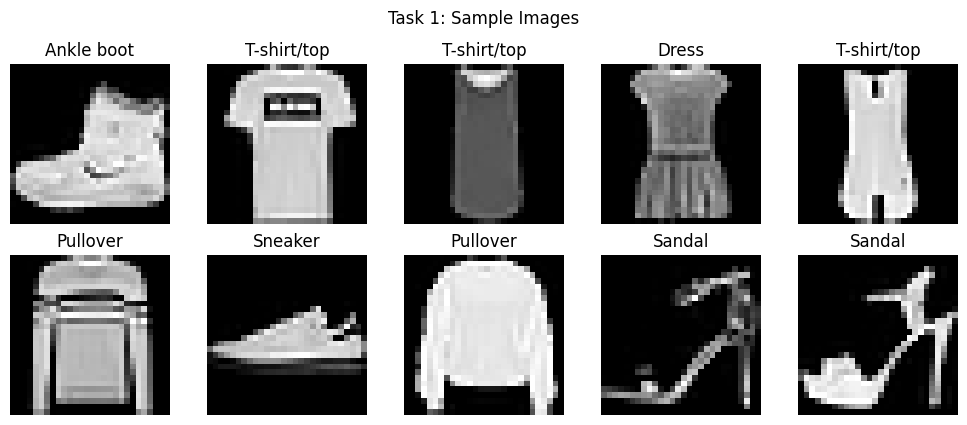

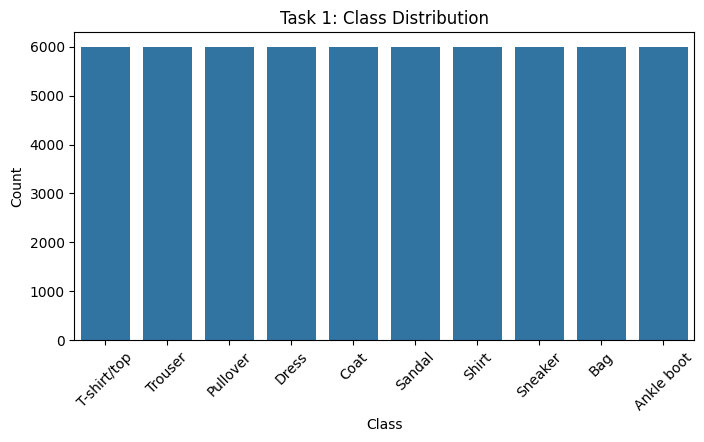

Before Preprocessing:
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
After Preprocessing:
Train images shape: (60000, 784)
Train labels shape: (60000, 10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8171 - loss: 0.5155 - val_accuracy: 0.8558 - val_loss: 0.3992
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8631 - loss: 0.3780 - val_accuracy: 0.8723 - val_loss: 0.3608
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8757 - loss: 0.3370 - val_accuracy: 0.8760 - val_loss: 0.3472
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8837 - loss: 0.3171 - val_accuracy: 0.8781 - val_loss: 0.3317
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8909 - loss: 0.2945 - val_accuracy: 0.8802 - val_loss: 0.3375
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8958 - loss: 0.2830 - val_accuracy: 0.8858 - val_loss: 0.3204
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9001 - loss: 0.2692 - val_accuracy: 0.8819 - val_loss: 0.3253
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9032 - loss: 0.2592 -

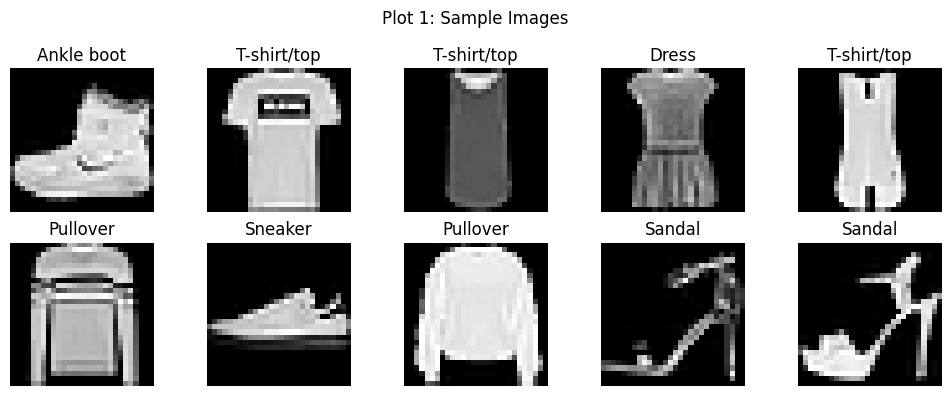

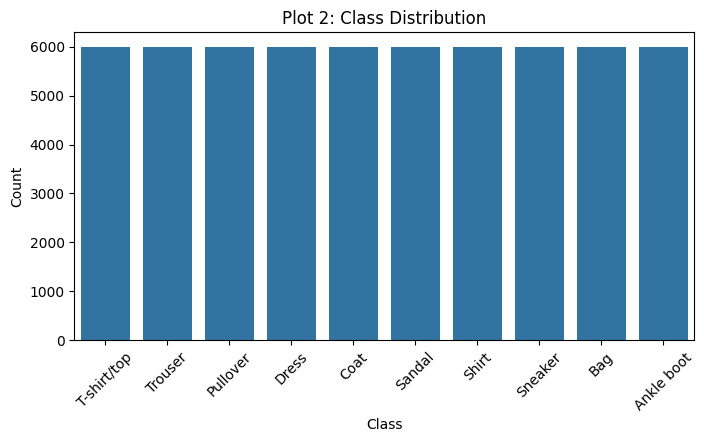

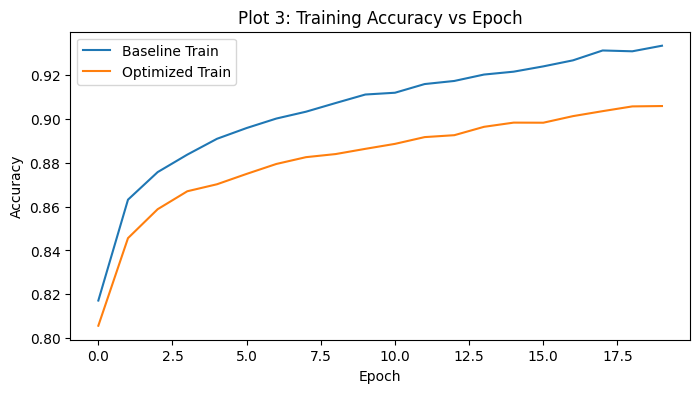

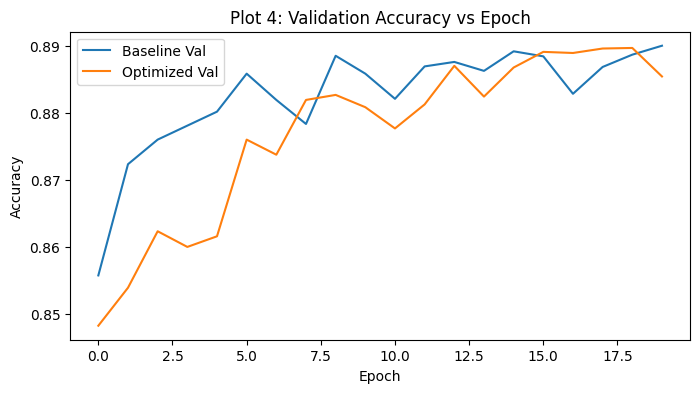

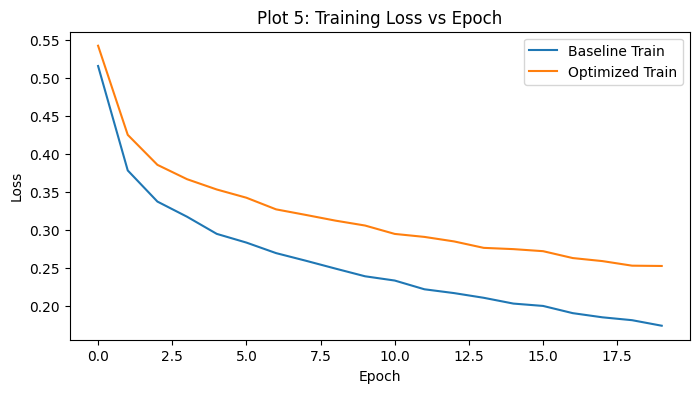

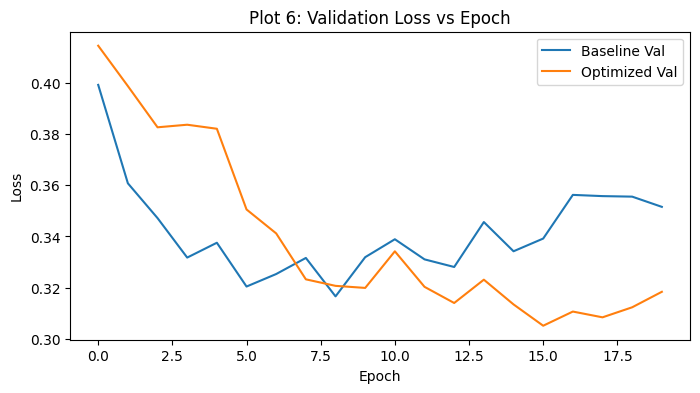

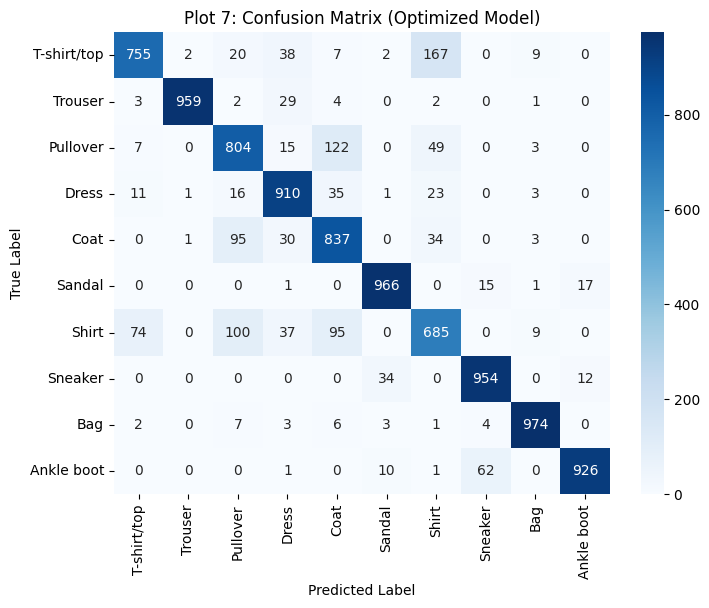

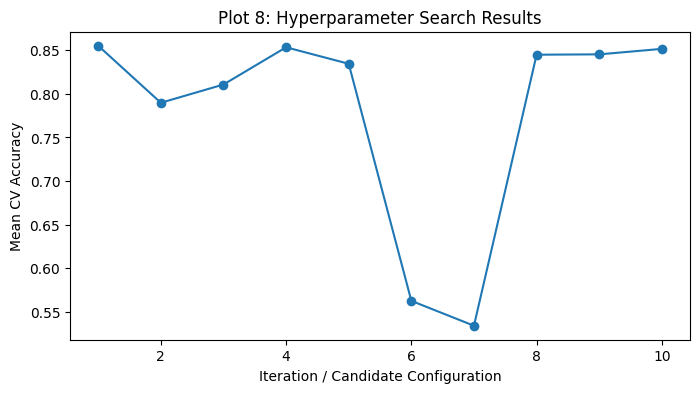

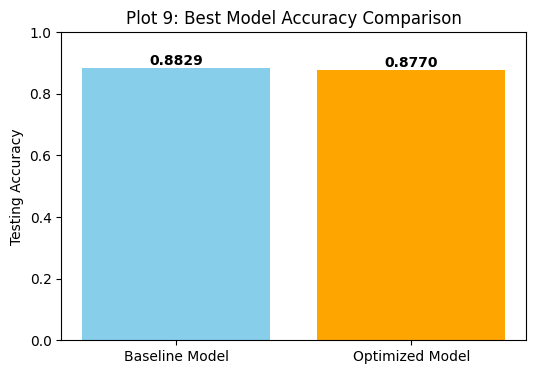

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

# Task 1
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("X_train shape:", X_train_raw.shape)
print("y_train shape:", y_train_raw.shape)
print("X_test shape:", X_test_raw.shape)
print("y_test shape:", y_test_raw.shape)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(class_names[y_train_raw[i]])
    plt.axis('off')
plt.tight_layout()
plt.suptitle("Task 1: Sample Images", y=1.05)
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x=y_train_raw)
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Task 1: Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Task 2
X_train_flat = X_train_raw.reshape((X_train_raw.shape[0], 28 * 28))
X_test_flat = X_test_raw.reshape((X_test_raw.shape[0], 28 * 28))

X_train = X_train_flat.astype('float32') / 255.0
X_test = X_test_flat.astype('float32') / 255.0

y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

print("Before Preprocessing:")
print("Train images shape:", X_train_raw.shape)
print("Train labels shape:", y_train_raw.shape)
print("After Preprocessing:")
print("Train images shape:", X_train.shape)
print("Train labels shape:", y_train.shape)

# Task 3
baseline_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.summary()

# Task 4
baseline_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Task 5
y_pred_probs_base = baseline_model.predict(X_test)
y_pred_base = np.argmax(y_pred_probs_base, axis=1)

base_acc = accuracy_score(y_test_raw, y_pred_base)
base_prec, base_rec, base_f1, _ = precision_recall_fscore_support(y_test_raw, y_pred_base, average='weighted')

print(f"Baseline Accuracy: {base_acc:.4f}")
print(f"Baseline Precision: {base_prec:.4f}")
print(f"Baseline Recall: {base_rec:.4f}")
print(f"Baseline F1-Score: {base_f1:.4f}")

cm_base = confusion_matrix(y_test_raw, y_pred_base)
print("\nConfusion Matrix:\n", cm_base)
print("\nClassification Report:\n", classification_report(y_test_raw, y_pred_base, target_names=class_names))

# Hyperparameter Optimisation
def create_mlp_model(hidden_layers=2, hidden_neurons=128, learning_rate=0.001,
                     optimizer_type='Adam', activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))

    if optimizer_type == 'Adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_type == 'SGD':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer_type == 'RMSprop':
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

sk_model = KerasClassifier(
    model=create_mlp_model,
    verbose=0
)

param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__optimizer_type': ['SGD', 'Adam', 'RMSprop'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}

random_search = RandomizedSearchCV(
    estimator=sk_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1
)

search_results = random_search.fit(X_train[:10000], y_train[:10000])

print("Best Hyperparameters:", search_results.best_params_)
print("Best Cross-Validation Accuracy:", search_results.best_score_)

best_params = search_results.best_params_

optimized_model = create_mlp_model(
    hidden_layers=best_params['model__hidden_layers'],
    hidden_neurons=best_params['model__hidden_neurons'],
    learning_rate=best_params['model__learning_rate'],
    optimizer_type=best_params['model__optimizer_type'],
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate']
)

history_opt = optimized_model.fit(
    X_train, y_train,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

y_pred_probs_opt = optimized_model.predict(X_test)
y_pred_opt = np.argmax(y_pred_probs_opt, axis=1)

opt_acc = accuracy_score(y_test_raw, y_pred_opt)
opt_prec, opt_rec, opt_f1, _ = precision_recall_fscore_support(y_test_raw, y_pred_opt, average='weighted')

# Mandatory Plots
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(class_names[y_train_raw[i]])
    plt.axis('off')
plt.suptitle("Plot 1: Sample Images")
plt.tight_layout()
plt.savefig("plot1_sample_images.eps", format='eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x=y_train_raw)
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Plot 2: Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("plot2_class_distribution.eps", format='eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_baseline.history['accuracy'], label='Baseline Train')
plt.plot(history_opt.history['accuracy'], label='Optimized Train')
plt.title("Plot 3: Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("plot3_accuracy_vs_epoch.eps", format='eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Val')
plt.plot(history_opt.history['val_accuracy'], label='Optimized Val')
plt.title("Plot 4: Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("plot4_val_accuracy_vs_epoch.eps", format='eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_baseline.history['loss'], label='Baseline Train')
plt.plot(history_opt.history['loss'], label='Optimized Train')
plt.title("Plot 5: Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("plot5_loss_vs_epoch.eps", format='eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_baseline.history['val_loss'], label='Baseline Val')
plt.plot(history_opt.history['val_loss'], label='Optimized Val')
plt.title("Plot 6: Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("plot6_val_loss_vs_epoch.eps", format='eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
cm_opt = confusion_matrix(y_test_raw, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Plot 7: Confusion Matrix (Optimized Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("plot7_confusion_matrix.eps", format='eps', bbox_inches='tight')
plt.show()

cv_scores = search_results.cv_results_['mean_test_score']
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o')
plt.title("Plot 8: Hyperparameter Search Results")
plt.xlabel("Iteration / Candidate Configuration")
plt.ylabel("Mean CV Accuracy")
plt.savefig("plot8_hyperparameter_search.eps", format='eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(['Baseline Model', 'Optimized Model'], [base_acc, opt_acc], color=['skyblue', 'orange'])
plt.ylabel("Testing Accuracy")
plt.title("Plot 9: Best Model Accuracy Comparison")
for i, v in enumerate([base_acc, opt_acc]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.ylim(0, 1.0)
plt.savefig("plot9_best_model_comparison.eps", format='eps', bbox_inches='tight')
plt.show()